In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score , ConfusionMatrixDisplay, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score

%matplotlib inline

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

df = pd.read_csv('diabetes.csv')

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 768 rows x 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [90]:
# ----------------Dataset INFO-------------------------------
print("Data Types")
df.info()
print("Statistical summary")
df.describe().round(2)

Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Statistical summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Class Distribution
Non-Diabetic (0): 500 65.1% 
Non-Diabetic (1): 268 34.9% 


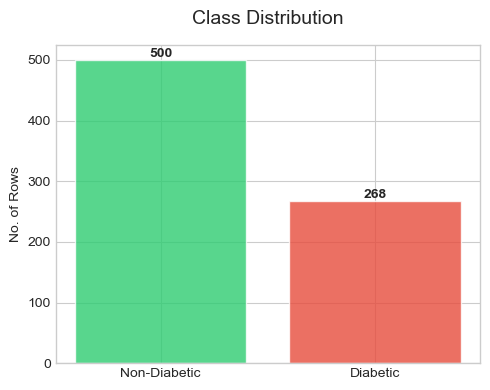

In [94]:
#============Class Balance===============
counts = df['Outcome'].value_counts()
percentages = df['Outcome'].value_counts(normalize=True)*100

print("Class Distribution")
print(f"Non-Diabetic (0): {counts[0]} {percentages[0]:.1f}% ")
print(f"Non-Diabetic (1): {counts[1]} {percentages[1]:.1f}% ")

fig,ax = plt.subplots(figsize=(5,4))
ax.bar(['Non-Diabetic','Diabetic'],counts,
      color= ['#2ecc71','#e74c3c'], alpha= 0.8, edgecolor='white')
ax.set_title("Class Distribution", fontsize=14, pad=15)
ax.set_ylabel('No. of Rows')
for i, v  in enumerate(counts):
    ax.text(i,v + 5,str(v), ha='center', fontweight='bold' )
plt.tight_layout()
plt.show()

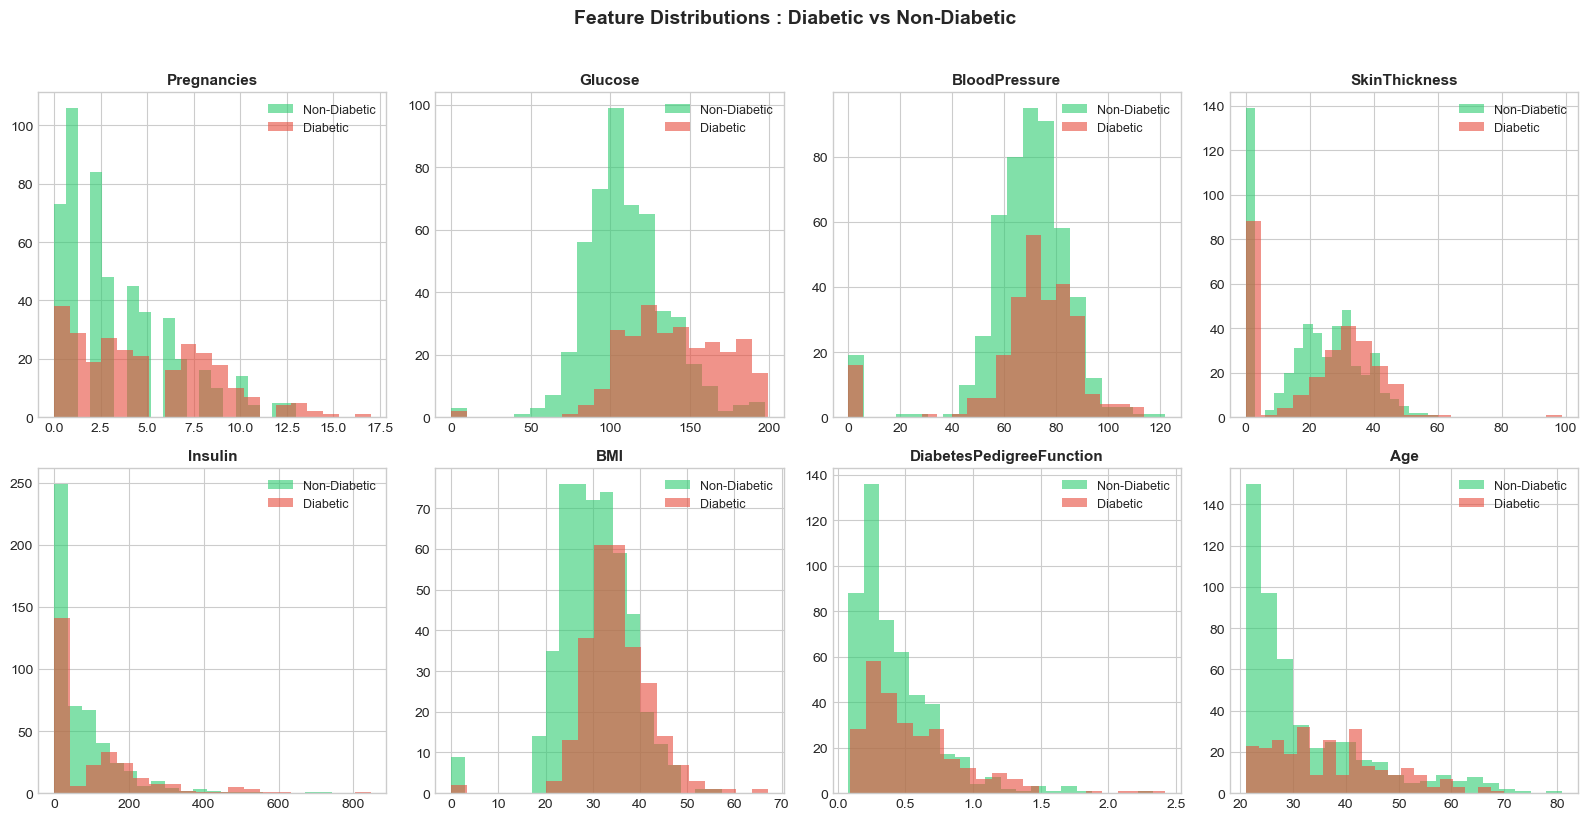

In [96]:
#==========Feature Distribution================
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig,axes = plt.subplots(2,4, figsize = (16,8))
axes = axes.flatten()
for i, feature in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][feature],bins=20, alpha=0.6, color = '#2ecc71' , label='Non-Diabetic')
    axes[i].hist(df[df['Outcome']==1][feature],bins=20, alpha=0.6, color = '#e74c3c' , label='Diabetic')
    axes[i].set_title(feature, fontsize=11,fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions : Diabetic vs Non-Diabetic', fontsize=14, fontweight='bold', y= 1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png',dpi=150,bbox_inches='tight')
plt.show()

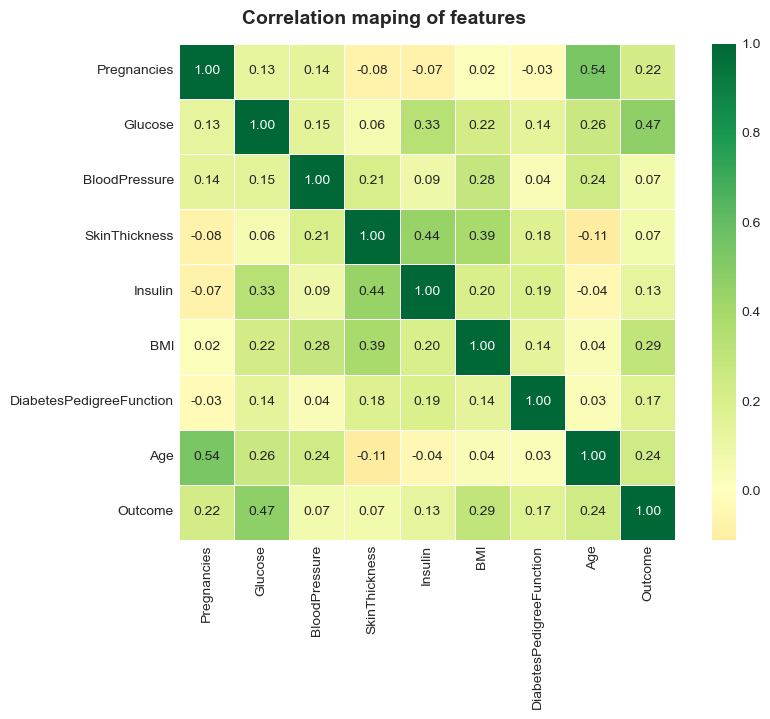

In [98]:
#================Correlation Maping==================

fig,ax = plt.subplots(figsize=(9,7))

corr_matrix = df.corr().round(2)
sns.heatmap(corr_matrix,
           annot=True,
           fmt='.2f',
           cmap='RdYlGn',
           center=0,
           square=True,
           linewidths=0.5,
            ax=ax)


plt.tight_layout()
plt.suptitle("Correlation maping of features",fontsize=14,fontweight='bold',y=1.02)
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches = 'tight')
plt.show()

In [100]:
#=======================Data Preprocessing===================

#====================removing missing values=================

df_clean = df.copy()

zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Missing before cleaning:")
for col in zero_not_valid:
    count =(df_clean[col] == 0).sum()
    print(f" {col}:{count} zeros")
    
for col in zero_not_valid:
    median_val = df_clean[df_clean[col] != 0 ][col].median()
    df_clean[col]= df_clean[col].replace(0,median_val)

print("Missing after cleaning: ")
for col in zero_not_valid:
    count =(df_clean[col] == 0).sum()
    print(f" {col}:{count} zeros")

Missing before cleaning:
 Glucose:5 zeros
 BloodPressure:35 zeros
 SkinThickness:227 zeros
 Insulin:374 zeros
 BMI:11 zeros
Missing after cleaning: 
 Glucose:0 zeros
 BloodPressure:0 zeros
 SkinThickness:0 zeros
 Insulin:0 zeros
 BMI:0 zeros


In [7]:
#===========Splitting Features and Target================

X= df_clean.drop('Outcome',axis=1)
y=df_clean['Outcome']

#===========Train/Test the split=======================

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state= 42, stratify =y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train outcome balance : {y_train.value_counts().to_dict()}")
print(f"Test outcome balance : {y_test.value_counts().to_dict()}")

Training set: 614 samples
Test set: 154 samples
Train outcome balance : {0: 400, 1: 214}
Test outcome balance : {0: 100, 1: 54}


In [8]:
#===================Feature Scaling=====================
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0).round(2))  
print(X_test_scaled.std(axis=0).round(2))   

[-0. -0.  0. -0. -0. -0. -0. -0.]
[1.08 1.07 0.92 0.94 1.41 1.04 1.01 0.97]


In [9]:
#=====================Training Logistic Regression===========

lr_model = LogisticRegression(
    max_iter= 1000,
    random_state = 42,
    solver = 'lbfgs'
)
lr_model.fit(X_train_scaled,y_train)

print("Logistic Regression trained!")
print(f"Training accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy:     {lr_model.score(X_test_scaled, y_test):.4f}")

Logistic Regression trained!
Training accuracy: 0.7964
Test accuracy:     0.7078


In [10]:
#==================Training Linear Discriminant Analysis==================
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled,y_train)
print("LDA trained:")
print(f"Training acccuracy: {lda_model.score(X_train_scaled,y_train):.4f}")
print(f"Test accuracy:{lda_model.score(X_test_scaled, y_test):.4f}")


LDA trained:
Training acccuracy: 0.7915
Test accuracy:0.7013


In [11]:
#==================Classification reports==================
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_lda = lda_model.predict(X_test_scaled)

print("Logistic Regression - Classification report")
print(classification_report(y_test, y_pred_lr, target_names= ['Non-Diabetic','Diabetic']))
print("LDA- Classification Report")
print(classification_report(y_test, y_pred_lda, target_names=['Non-Diabetic','Diabetic']))


Logistic Regression - Classification report
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

LDA- Classification Report
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



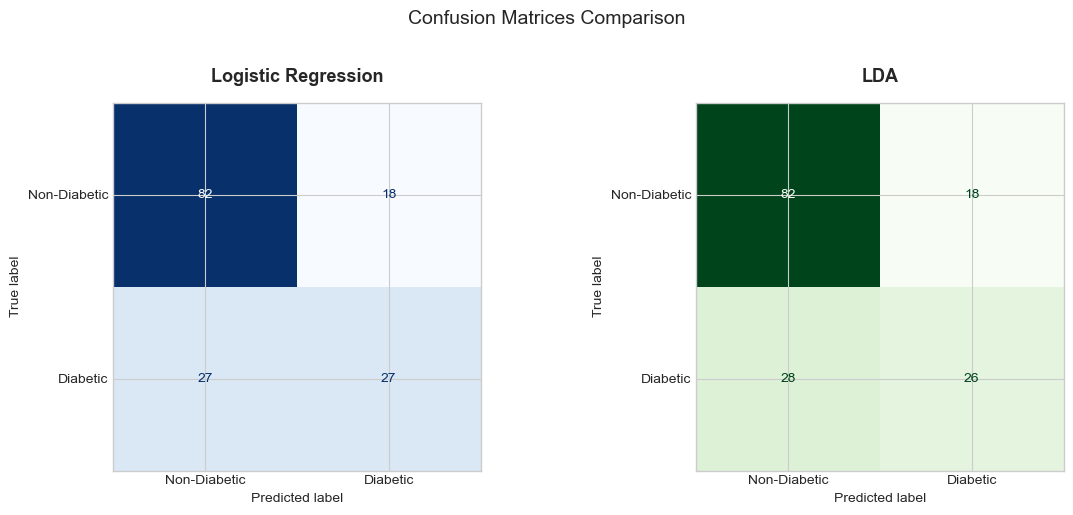

In [12]:
#===================Confusion matrix=====================

fig, axes = plt.subplots(1,2,figsize=(12,5))

for ax, model, name, color in zip(axes,[lr_model,lda_model],['Logistic Regression','LDA'],['Blues','Greens']):
    cm= confusion_matrix(y_test, model.predict(X_test_scaled))
    disp= ConfusionMatrixDisplay(cm, display_labels=['Non-Diabetic','Diabetic'])
    disp.plot(ax=ax, cmap=color, colorbar= False)
    ax.set_title(name,fontsize=13,fontweight='bold',pad=15)
    

plt.suptitle('Confusion Matrices Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches = 'tight')
plt.show()

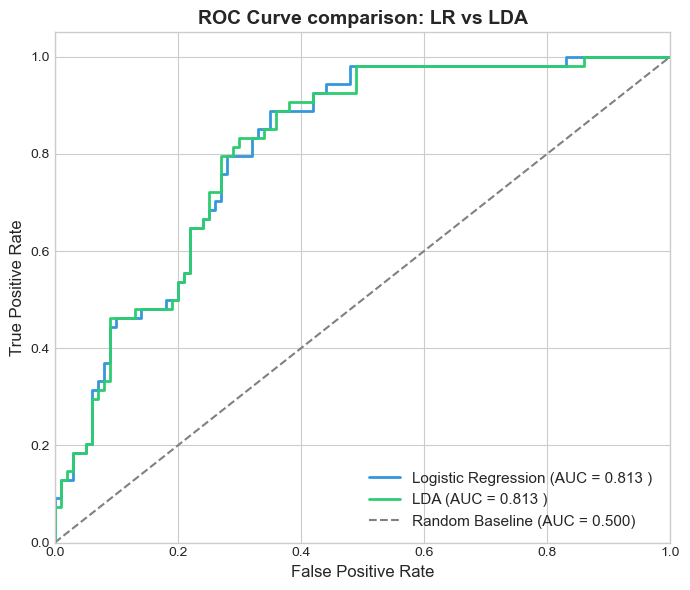

In [43]:
fig,ax = plt.subplots(figsize=(7,6))

for model,name,color in[(lr_model, 'Logistic Regression', '#3498db'),(lda_model,'LDA','#2ecc71')]:
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr,tpr, _ = roc_curve(y_test,y_prob)
    roc_auc = auc(fpr,tpr)

    ax.plot(fpr,tpr,lw=2,color=color,label=f'{name} (AUC = {roc_auc:.3f} ) ')
ax.plot([0,1],[0,1],'--',color='gray',label = 'Random Baseline (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve comparison: LR vs LDA', fontsize = 14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0,1])
ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show() 



In [57]:
#================Overall comparison=====================

results = {}

for name, model in [('Logistic Regression',lr_model),('LDA',lda_model)]:
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    results[name]={
        'Accuracy': round(accuracy_score(y_test,y_pred),4),
        'Precision': round(precision_score(y_test,y_pred),4),
        'Recall': round(recall_score(y_test,y_pred),4),
        'F1- Score': round(f1_score(y_test,y_pred),4),
        'AUC_ROC': round(roc_auc_score(y_test,y_pred),4),
    }
results_df = pd.DataFrame(results).T
print("Final Comparison:")
print(results_df.to_string())

for col in results_df.columns:
    winner = results_df[col].idxmax()
    print(f" {col}: {winner} ({results_df.loc[winner,col]}) ")

Final Comparison:
                     Accuracy  Precision  Recall  F1- Score  AUC_ROC
Logistic Regression    0.7078     0.6000  0.5000     0.5455   0.6600
LDA                    0.7013     0.5909  0.4815     0.5306   0.6507
 Accuracy: Logistic Regression (0.7078) 
 Precision: Logistic Regression (0.6) 
 Recall: Logistic Regression (0.5) 
 F1- Score: Logistic Regression (0.5455) 
 AUC_ROC: Logistic Regression (0.66) 


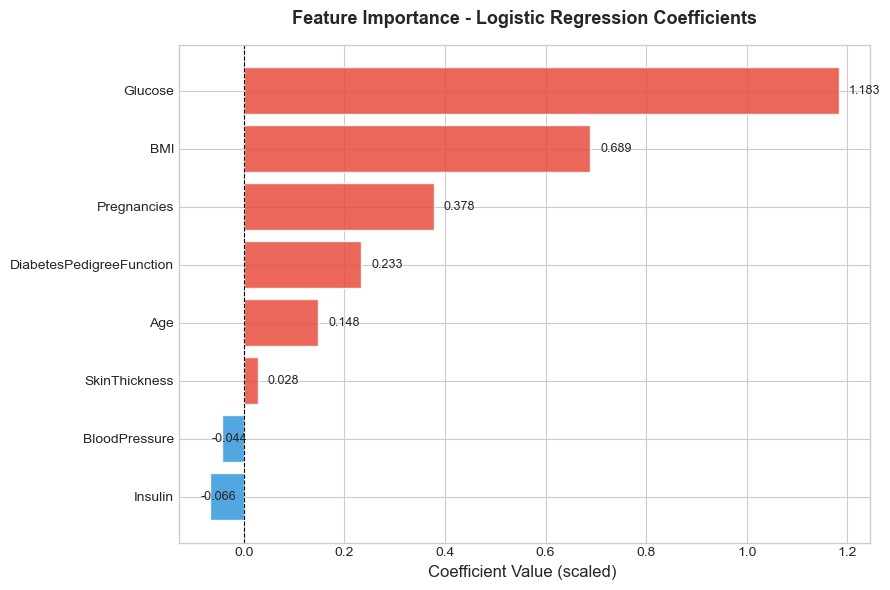

In [106]:
#================== Feature Importance======================
feature_names = list(X.columns)
coefficients = lr_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature' : feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending =True)

colors = ['#e74c3c' if c>0 else '#3498db' for c in importance_df['Coefficient']]

fig,ax = plt.subplots(figsize=(9,6))
bars = ax.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, alpha = 0.85,edgecolor = 'white')

ax.axvline(0,color = 'black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value (scaled) ',fontsize = 12)
ax.set_title('Feature Importance - Logistic Regression Coefficients',fontsize= 13, fontweight= 'bold',pad=15)

for bar, val in zip(bars, importance_df['Coefficient']):
    ax.text(val + (0.02 if val >=0 else -0.02),bar.get_y() + bar.get_height()/2,f'{val:.3f}', va='center' , fontsize= 9)

plt.tight_layout()
plt.savefig('feature_importance.png',dpi= 150, bbox_inches='tight')
plt.show()